<a href="https://colab.research.google.com/github/VintaBytes/Ciencia-de-datos/blob/main/cursos/machine-learning-python2/Clase05/Division_y_validacion_del_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# División y validación del dataset

Dataset: [Popular Video Games 1980–2023](https://www.kaggle.com/datasets/arnabchaki/popular-video-games-1980-2023/data)

## Objetivo de este cuaderno

En esta clase todavía **no vamos a estudiar en profundidad cómo funciona un algoritmo de Machine Learning**.

Nuestro objetivo es anterior y muy importante: comprender **cómo debemos organizar los datos para entrenar y evaluar un modelo de manera confiable**.

Al finalizar la práctica deberíamos poder responder estas preguntas:

- ¿Por qué no conviene entrenar y evaluar un modelo con los mismos datos?
- ¿Qué son los conjuntos de **entrenamiento** y **prueba**?
- ¿Qué significan `X` e `y`?
- ¿Para qué sirven `random_state` y `stratify`?
- ¿Qué nos dicen los resultados obtenidos en entrenamiento y prueba?
- ¿Qué significan **overfitting** y **underfitting**?
- ¿Por qué una sola división de los datos puede ser engañosa?
- ¿Qué aporta la **validación cruzada**?

> **Importante:** vamos a utilizar un modelo sencillo únicamente como una **herramienta de medición**. Por ahora puede pensarse como una caja negra: recibe ejemplos, aprende algo a partir de ellos y luego intenta clasificar casos que no vio.

## 1. Presentación del dataset

Trabajaremos con el dataset **Popular Video Games 1980–2023**.

Contiene información sobre videojuegos publicados entre 1980 y 2023, incluyendo valoraciones y distintas medidas relacionadas con la actividad de los usuarios.

No intentaremos construir el “mejor modelo posible”. El dataset nos servirá para estudiar el proceso de **división y validación de datos**.

## 2. Importar las bibliotecas necesarias

Usaremos:

- `pandas`, para trabajar con tablas;
- `matplotlib`, para algunos gráficos;
- `kagglehub`, para descargar el dataset si no está disponible localmente;
- `os`, para manejar la ruta del archivo.

Las herramientas de `scikit-learn` aparecerán más adelante, cuando realmente las necesitemos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

## 3. Cargar el dataset

Primero intentamos abrir `games.csv` desde el entorno actual.

Si el archivo no está disponible, el cuaderno lo descarga desde Kaggle y luego lo carga en un DataFrame llamado `games`.

In [2]:
try:
    games = pd.read_csv("games.csv")
    print("Dataset cargado desde el archivo local 'games.csv'")
except Exception:
    print("No se encontró 'games.csv' en el entorno local.")
    print("Descargando dataset desde Kaggle...")

    ruta_dataset = kagglehub.dataset_download(
        "arnabchaki/popular-video-games-1980-2023"
    )
    ruta_csv = os.path.join(ruta_dataset, "games.csv")

    games = pd.read_csv(ruta_csv)
    print("Dataset descargado y cargado correctamente desde Kaggle")

print("\nCantidad de filas y columnas:", games.shape)

No se encontró 'games.csv' en el entorno local.
Descargando dataset desde Kaggle...


100%|██████████| 1.11M/1.11M [00:00<00:00, 2.23MB/s]

Extracting files...


Dataset descargado y cargado correctamente desde Kaggle

Cantidad de filas y columnas: (1512, 14)


## 4. Exploración inicial

Antes de pensar en Machine Learning debemos mirar los datos.

Nos concentraremos en:

- `Rating`: valoración del juego;
- `Times Listed`;
- `Number of Reviews`;
- `Plays`;
- `Playing`;
- `Backlogs`;
- `Wishlist`.

Algunas de estas columnas contienen valores como `3.9K` o `17K`. Aunque para nosotros significan 3900 y 17000, para Python esos valores pueden estar almacenados como **texto**. Antes de usarlos habrá que convertirlos a números.

In [3]:
columnas_interes = [
    "Rating",
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

display(games[columnas_interes].head(10))

print("\nValores nulos:")
print(games[columnas_interes].isnull().sum())

,Rating,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,4.5,3.9K,3.9K,17K,3.8K,4.6K,4.8K
1,4.3,2.9K,2.9K,21K,3.2K,6.3K,3.6K
2,4.4,4.3K,4.3K,30K,2.5K,5K,2.6K
3,4.2,3.5K,3.5K,28K,679,4.9K,1.8K
4,4.4,3K,3K,21K,2.4K,8.3K,2.3K
5,4.3,2.3K,2.3K,33K,1.8K,1.1K,230
6,4.2,1.6K,1.6K,7.2K,1.1K,4.5K,3.8K
7,4.3,2.1K,2.1K,9.2K,759,3.4K,3.3K
8,3.0,867,867,25K,470,776,126
9,4.3,2.9K,2.9K,18K,1.1K,6.2K,3.6K



Valores nulos:
Rating               13
Times Listed          0
Number of Reviews     0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64


## 5. Preparar las columnas numéricas

Convertiremos expresiones como:

- `3.9K` → `3900`
- `17K` → `17000`
- `230` → `230`

Este paso no tiene todavía relación con el entrenamiento del modelo: es simplemente **preparación de datos**, algo que ya venimos realizando en las clases anteriores.

In [4]:
def convertir_k_a_numero(valor):
    if pd.isna(valor):
        return None

    valor = str(valor).strip().upper()

    if valor.endswith("K"):
        return float(valor[:-1]) * 1000

    return float(valor)


columnas_numericas_texto = [
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

games_transformado = games.copy()

for columna in columnas_numericas_texto:
    games_transformado[columna] = (
        games_transformado[columna].apply(convertir_k_a_numero)
    )

display(games_transformado[columnas_numericas_texto].head(10))
print("\nTipos de datos:")
print(games_transformado[columnas_numericas_texto].dtypes)

,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0
1,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0
2,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0
3,3500.0,3500.0,28000.0,679.0,4900.0,1800.0
4,3000.0,3000.0,21000.0,2400.0,8300.0,2300.0
5,2300.0,2300.0,33000.0,1800.0,1100.0,230.0
6,1600.0,1600.0,7200.0,1100.0,4500.0,3800.0
7,2100.0,2100.0,9200.0,759.0,3400.0,3300.0
8,867.0,867.0,25000.0,470.0,776.0,126.0
9,2900.0,2900.0,18000.0,1100.0,6200.0,3600.0



Tipos de datos:
Times Listed         float64
Number of Reviews    float64
Plays                float64
Playing              float64
Backlogs             float64
Wishlist             float64
dtype: object


# Antes de dividir los datos: ¿qué queremos predecir?

Para utilizar un modelo necesitamos formular una pregunta concreta.

En esta práctica preguntaremos:

> **¿Podemos distinguir los juegos con valoración alta de los juegos con valoración menor utilizando información sobre la actividad de los usuarios?**

Vamos a considerar:

- `1` → juego con `Rating >= 4.0`
- `0` → juego con `Rating < 4.0`

La nueva columna `Alta_Valoracion` será nuestra **variable objetivo**.

No estamos afirmando que 4.0 sea un límite universal. Elegimos ese valor solamente para construir un problema sencillo de **clasificación** con dos posibles respuestas.

In [5]:
# Eliminamos únicamente las filas donde falta Rating,
# porque no podríamos decidir a qué clase pertenecen.
games_modelo = games_transformado.dropna(subset=["Rating"]).copy()

games_modelo["Alta_Valoracion"] = (
    games_modelo["Rating"] >= 4.0
).astype(int)

print("Cantidad de juegos en cada clase:")
print(games_modelo["Alta_Valoracion"].value_counts())

print("\nProporción de cada clase:")
print(games_modelo["Alta_Valoracion"].value_counts(normalize=True))

Cantidad de juegos en cada clase:
Alta_Valoracion
0    918
1    581
Name: count, dtype: int64

Proporción de cada clase:
Alta_Valoracion
0    0.612408
1    0.387592
Name: proportion, dtype: float64


## 6. ¿Qué significan `X` e `y`?

Esta notación aparece continuamente en Machine Learning:

- **`X`** contiene las columnas que entregamos al modelo como información de entrada. A estas columnas se las suele llamar **variables predictoras**, **características** o *features*.
- **`y`** contiene aquello que queremos que el modelo aprenda a predecir. Se denomina **variable objetivo** o *target*.

En nuestro caso:

`X` = información sobre actividad de los usuarios.

`y` = `Alta_Valoracion`, es decir, 0 o 1.

> El modelo recibirá las columnas de `X` e intentará aprender alguna relación que le permita aproximarse a `y`.

In [6]:
features = [
    "Times Listed",
    "Number of Reviews",
    "Plays",
    "Playing",
    "Backlogs",
    "Wishlist"
]

X = games_modelo[features]
y = games_modelo["Alta_Valoracion"]

print("X tiene forma:", X.shape)
print("y tiene forma:", y.shape)

print("\nPrimeras filas de X:")
display(X.head())

print("\nPrimeros valores de y:")
display(y.head())

X tiene forma: (1499, 6)
y tiene forma: (1499,)

Primeras filas de X:


,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
0,3900.0,3900.0,17000.0,3800.0,4600.0,4800.0
1,2900.0,2900.0,21000.0,3200.0,6300.0,3600.0
2,4300.0,4300.0,30000.0,2500.0,5000.0,2600.0
3,3500.0,3500.0,28000.0,679.0,4900.0,1800.0
4,3000.0,3000.0,21000.0,2400.0,8300.0,2300.0



Primeros valores de y:


,Alta_Valoracion
0,1
1,1
2,1
3,1
4,1


# 7. División del dataset: entrenamiento y prueba

Ahora aparece la idea central de la clase.

Si entregáramos **todos los datos** al modelo para que aprenda y después lo evaluáramos con esos mismos datos, no sabríamos si realmente aprendió una regla útil o si simplemente se adaptó a los ejemplos que ya conocía.

Por eso separamos los datos:

```text
Dataset completo
│
├── Entrenamiento → datos que el modelo puede usar para aprender
│
└── Prueba         → datos que reservamos para evaluar al modelo
```

El conjunto de prueba debe permanecer fuera del entrenamiento.

Es parecido a estudiar con una colección de ejercicios y después rendir una evaluación con ejercicios que no son exactamente los mismos.

## ¿Qué hacen `test_size`, `random_state` y `stratify`?

En `train_test_split()` usaremos tres parámetros importantes:

**`test_size`**

Indica qué proporción queda para prueba.

- `test_size=0.20` → 20 % prueba y 80 % entrenamiento.
- `test_size=0.30` → 30 % prueba y 70 % entrenamiento.

**`random_state`**

La división es aleatoria. Si no fijamos una semilla, cada ejecución podría producir grupos diferentes.

`random_state=42` hace que podamos repetir exactamente la misma división. El número 42 no tiene ninguna propiedad especial: podríamos utilizar otro.

**`stratify=y`**

Intenta conservar en entrenamiento y prueba aproximadamente la misma proporción de las clases 0 y 1 que existe en el dataset completo.

Esto es útil porque evita, por ejemplo, que por azar una de las particiones reciba una cantidad desproporcionada de juegos de alta valoración.

In [7]:
from sklearn.model_selection import train_test_split

# División 80/20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# División 70/30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("DIVISIÓN 80/20")
print("Entrenamiento:", X_train_80.shape[0], "filas")
print("Prueba:", X_test_80.shape[0], "filas")

print("\nDIVISIÓN 70/30")
print("Entrenamiento:", X_train_70.shape[0], "filas")
print("Prueba:", X_test_70.shape[0], "filas")

DIVISIÓN 80/20
Entrenamiento: 1199 filas
Prueba: 300 filas

DIVISIÓN 70/30
Entrenamiento: 1049 filas
Prueba: 450 filas


## Comprobemos el efecto de `stratify`

No alcanza con conocer el tamaño de cada conjunto. También conviene comprobar qué proporción de clases quedó en cada uno.

Si `stratify=y` hizo su trabajo, las proporciones deberían ser muy similares.

In [8]:
comparacion_clases = pd.DataFrame({
    "dataset_completo": y.value_counts(normalize=True).sort_index(),
    "train_80": y_train_80.value_counts(normalize=True).sort_index(),
    "test_80": y_test_80.value_counts(normalize=True).sort_index(),
    "train_70": y_train_70.value_counts(normalize=True).sort_index(),
    "test_70": y_test_70.value_counts(normalize=True).sort_index()
})

comparacion_clases.index = ["Clase 0", "Clase 1"]
display(comparacion_clases.round(3))

,dataset_completo,train_80,test_80,train_70,test_70
Clase 0,0.612,0.612,0.613,0.612,0.613
Clase 1,0.388,0.388,0.387,0.388,0.387


# 8. Nuestro primer contacto con un modelo

Hasta aquí **no entrenamos ningún modelo**. Solamente preparamos y dividimos datos.

Ahora necesitamos uno para poder comprobar si la división entre entrenamiento y prueba tiene sentido en la práctica.

Usaremos un **árbol de decisión** muy sencillo.

> **No es objetivo de esta clase aprender cómo funciona internamente un árbol de decisión.**

Por ahora alcanza con entender tres acciones:

1. **crear el modelo**;
2. **entrenarlo** con `.fit(X_train, y_train)`;
3. **pedirle predicciones** con `.predict(X_test)`.

En una clase posterior estudiaremos los modelos con más detalle.

Mantendremos exactamente el mismo tipo de modelo en todas las comparaciones. Así, lo que cambia principalmente es **cómo dividimos o validamos los datos**, que es el tema que queremos estudiar hoy.

## ¿Qué significa `accuracy`?

Para evaluar este problema utilizaremos **accuracy**, que puede interpretarse como la proporción de predicciones correctas.

Por ejemplo:

- `accuracy = 0.80` significa que aproximadamente el 80 % de los casos fueron clasificados correctamente;
- `accuracy = 0.65` significa aproximadamente un 65 %.

En este cuaderno hablaremos de **accuracy** o **exactitud**.

No debemos confundirla con la métrica llamada **precision**, que es otra medida diferente y que estudiaremos más adelante.

Antes de evaluar nuestro modelo también calcularemos una referencia muy sencilla: qué accuracy obtendríamos si siempre respondiéramos con la clase más frecuente. Esa referencia se denomina aquí **baseline**.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Baseline: acertaríamos esto si siempre eligiéramos la clase más frecuente.
baseline = y.value_counts(normalize=True).max()

print(f"Baseline de la clase mayoritaria: {baseline:.3f}")

Baseline de la clase mayoritaria: 0.612


In [10]:
def entrenar_y_evaluar(X_train, X_test, y_train, y_test):
    # El modelo se mantiene fijo.
    modelo = DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    return {
        "accuracy_entrenamiento": accuracy_score(y_train, pred_train),
        "accuracy_prueba": accuracy_score(y_test, pred_test)
    }


resultado_80 = entrenar_y_evaluar(
    X_train_80, X_test_80, y_train_80, y_test_80
)

resultado_70 = entrenar_y_evaluar(
    X_train_70, X_test_70, y_train_70, y_test_70
)

comparacion_splits = pd.DataFrame(
    [resultado_80, resultado_70],
    index=["80/20", "70/30"]
)

display(comparacion_splits.round(3))

,accuracy_entrenamiento,accuracy_prueba
80/20,0.745,0.683
70/30,0.738,0.709


## ¿Cómo leer esta tabla?

No buscamos decidir todavía cuál es el “mejor modelo”.

Queremos observar dos cosas:

**1. Rendimiento sobre entrenamiento**

Nos dice qué tan bien responde el modelo frente a datos que sí estuvieron disponibles durante el aprendizaje.

**2. Rendimiento sobre prueba**

Nos interesa especialmente porque corresponde a datos que el modelo **no utilizó para aprender**.

Es normal que ambos valores no sean idénticos.

También podemos comparar las dos particiones, 80/20 y 70/30. Al cambiar la cantidad de datos destinada al entrenamiento y a la prueba, los resultados pueden cambiar.

Eso nos lleva a una pregunta importante:

> ¿Qué tan confiable es una evaluación basada en una única división aleatoria?

# 9. Overfitting y underfitting

Estos conceptos se entienden mejor comparando el desempeño en entrenamiento y en datos no vistos.

### Underfitting o subajuste

El modelo **no logra aprender suficientemente** los patrones del problema.

Una señal posible sería un rendimiento bajo tanto en entrenamiento como en prueba.

### Overfitting o sobreajuste

El modelo se adapta **demasiado** a los datos con los que fue entrenado.

Puede obtener un rendimiento muy alto en entrenamiento pero caer considerablemente cuando recibe datos nuevos.

### Generalización

Es lo que realmente buscamos: que lo aprendido con los datos de entrenamiento siga siendo útil con casos que el modelo no conocía.

Una tabla imaginaria puede ayudar:

| Situación hipotética | Entrenamiento | Prueba | Interpretación posible |
|---|---:|---:|---|
| A | 0.63 | 0.61 | posible underfitting |
| B | 0.99 | 0.70 | posible overfitting |
| C | 0.86 | 0.83 | generalización razonable |

> Estos valores son ejemplos inventados para comprender la idea. No son reglas automáticas ni límites universales.

Una diferencia entre entrenamiento y prueba es una **señal para investigar**, no una prueba definitiva de overfitting.

## Algo importante sobre nuestra práctica

En la versión anterior de este cuaderno se comparaban árboles con distintas profundidades para intentar mostrar underfitting y overfitting.

El problema es que, con este dataset, los modelos más complejos podían obtener **mejor resultado de prueba al mismo tiempo que aumentaba la diferencia entre entrenamiento y prueba**. Eso hacía que la interpretación no fuera clara para una primera aproximación.

Por eso aquí no vamos a forzar una conclusión que los datos no muestran de manera limpia.

En esta clase nos quedamos con la idea conceptual:

- bajo rendimiento en entrenamiento y prueba → posible underfitting;
- rendimiento muy alto en entrenamiento y claramente peor en prueba → posible overfitting;
- resultados razonablemente buenos y cercanos → mejor señal de generalización.

Más adelante, cuando estudiemos modelos y complejidad, podremos analizar estos fenómenos con mayor profundidad.

# 10. Una sola división puede engañarnos

La división 80/20 que hicimos antes depende de una selección aleatoria de filas.

Aunque fijamos `random_state=42` para poder repetir el experimento, podríamos haber elegido otra semilla y obtenido otra partición.

Vamos a comprobarlo.

Mantendremos:

- el mismo dataset;
- el mismo porcentaje 80/20;
- el mismo tipo de modelo;

y cambiaremos únicamente la semilla utilizada para dividir los datos.

Si la evaluación cambia, veremos por qué puede ser peligroso sacar conclusiones a partir de una sola partición.

In [11]:
resultados_semillas = []

for semilla in range(10):
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=semilla,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    )

    modelo.fit(X_train_s, y_train_s)
    pred_test_s = modelo.predict(X_test_s)

    resultados_semillas.append({
        "semilla": semilla,
        "accuracy_prueba": accuracy_score(y_test_s, pred_test_s)
    })

df_semillas = pd.DataFrame(resultados_semillas)
display(df_semillas.round(3))

print("\nPromedio:", round(df_semillas["accuracy_prueba"].mean(), 3))
print("Mínimo:", round(df_semillas["accuracy_prueba"].min(), 3))
print("Máximo:", round(df_semillas["accuracy_prueba"].max(), 3))

,semilla,accuracy_prueba
0,0,0.710
1,1,0.733
2,2,0.723
3,3,0.717
4,4,0.727
5,5,0.723
6,6,0.693
7,7,0.723
8,8,0.707
9,9,0.747



Promedio: 0.72
Mínimo: 0.693
Máximo: 0.747


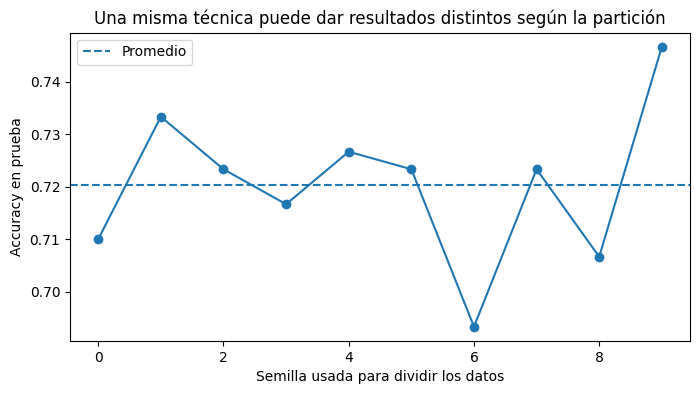

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(
    df_semillas["semilla"],
    df_semillas["accuracy_prueba"],
    marker="o"
)
plt.axhline(
    df_semillas["accuracy_prueba"].mean(),
    linestyle="--",
    label="Promedio"
)

plt.xlabel("Semilla usada para dividir los datos")
plt.ylabel("Accuracy en prueba")
plt.title("Una misma técnica puede dar resultados distintos según la partición")
plt.legend()
plt.show()

## ¿Qué aprendemos de este experimento?

El modelo no cambió, pero sí cambiaron las filas que quedaron en entrenamiento y prueba.

Por eso la accuracy puede variar.

Esto no significa que `train_test_split()` esté mal. Significa que **una única división nos muestra solamente una de muchas particiones posibles**.

Cuando el dataset es pequeño o queremos una evaluación más estable, necesitamos una estrategia que no dependa tanto de una sola división.

Ahí aparece la **validación cruzada**.

# 11. Validación cruzada K-Fold

En una validación cruzada de 5 pliegues (*5-fold cross validation*) dividimos los datos en cinco partes.

El proceso puede imaginarse así:

| Vuelta | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 |
|---|---|---|---|---|---|
| 1 | **Prueba** | Entrena | Entrena | Entrena | Entrena |
| 2 | Entrena | **Prueba** | Entrena | Entrena | Entrena |
| 3 | Entrena | Entrena | **Prueba** | Entrena | Entrena |
| 4 | Entrena | Entrena | Entrena | **Prueba** | Entrena |
| 5 | Entrena | Entrena | Entrena | Entrena | **Prueba** |

El modelo se entrena y evalúa cinco veces.

Así obtenemos **cinco resultados**, no uno solo.

Luego podemos calcular:

- el **promedio**, que resume el rendimiento;
- el **desvío estándar**, que nos da una idea de cuánto variaron los resultados entre pliegues.

Como nuestro problema tiene dos clases, utilizaremos `StratifiedKFold`, que intenta mantener aproximadamente la proporción de clases en cada pliegue.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

modelo_cv = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_cv = cross_val_score(
    modelo_cv,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy en cada fold:")
for numero, score in enumerate(scores_cv, start=1):
    print(f"Fold {numero}: {score:.3f}")

print(f"\nAccuracy promedio: {scores_cv.mean():.3f}")
print(f"Desvío estándar: {scores_cv.std():.3f}")

Accuracy en cada fold:
Fold 1: 0.700
Fold 2: 0.710
Fold 3: 0.713
Fold 4: 0.743
Fold 5: 0.699

Accuracy promedio: 0.713
Desvío estándar: 0.016


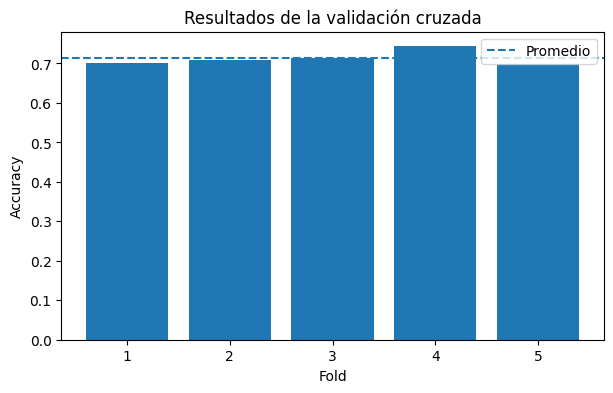

In [14]:
df_cv = pd.DataFrame({
    "fold": range(1, 6),
    "accuracy": scores_cv
})

plt.figure(figsize=(7, 4))
plt.bar(df_cv["fold"].astype(str), df_cv["accuracy"])
plt.axhline(
    scores_cv.mean(),
    linestyle="--",
    label="Promedio"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Resultados de la validación cruzada")
plt.legend()
plt.show()

## ¿Por qué la validación cruzada es más informativa?

Con una única división podríamos haber tenido, por azar, un conjunto de prueba particularmente fácil o difícil.

Con validación cruzada cada parte de los datos participa alguna vez en la evaluación.

El promedio de los cinco resultados nos da una estimación menos dependiente de una única partición.

> **Nota para más adelante:** en proyectos más avanzados es habitual reservar un conjunto de prueba final y utilizar la validación cruzada sobre los datos de entrenamiento para comparar alternativas. En esta clase nos interesa primero comprender el mecanismo básico.

# 12. Actividad de interpretación

Respondé a partir de los resultados obtenidos en tu propia ejecución.

1. ¿Cuántas filas quedaron en entrenamiento y prueba con la división 80/20?
2. ¿Y con la división 70/30?
3. ¿Las proporciones de las clases 0 y 1 se mantuvieron parecidas en ambos conjuntos? ¿Qué parámetro ayudó a conseguirlo?
4. ¿Qué significa `random_state=42`?
5. ¿Qué representa `X`? ¿Qué representa `y`?
6. ¿Qué significa que el modelo tenga una accuracy de prueba determinada?
7. ¿El modelo superó la baseline de la clase mayoritaria?
8. ¿Los resultados de prueba fueron iguales para todas las semillas?
9. ¿Por qué esa variación justifica utilizar una estrategia como validación cruzada?
10. ¿Qué diferencia conceptual hay entre underfitting y overfitting?
11. ¿Por qué no sería correcto afirmar automáticamente que “una brecha grande siempre significa que debemos elegir otro modelo”?
12. ¿Qué información adicional aporta observar los cinco folds en lugar de una única partición train/test?

# Conclusiones

En esta práctica el protagonista no fue el algoritmo, sino **la forma en que evaluamos lo que aprende**.

Vimos que:

- primero debemos definir con claridad qué información será `X` y qué variable será `y`;
- no conviene entrenar y evaluar con los mismos datos;
- `train_test_split()` permite reservar datos que el modelo no vio durante el entrenamiento;
- `stratify` ayuda a conservar la proporción de clases;
- `random_state` permite reproducir una división aleatoria;
- comparar entrenamiento y prueba puede aportar señales de underfitting u overfitting;
- una sola partición puede producir una evaluación demasiado dependiente del azar;
- la validación cruzada repite el proceso con diferentes partes de los datos y permite obtener una estimación más robusta.

La idea más importante de la clase puede resumirse en una frase:

> **Un buen modelo no es solamente el que responde bien sobre los datos que ya vio, sino el que logra generalizar a datos nuevos.**

En las próximas clases comenzaremos a estudiar los modelos propiamente dichos. Cuando eso ocurra, estas herramientas nos permitirán evaluarlos de una manera mucho más cuidadosa.

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
